# Gold Extraction Template: Commentary → Structured JSON

This notebook defines the **gold extraction template** for converting book commentary
(Chernev's *Logical Chess: Move by Move*) into structured, verifiable JSON.

**Task**: Given FEN + move + engine analysis + book commentary → extract structured JSON.

**When include=true:**
```json
{
  "include": true,
  "book_commentary": "<the full original commentary>",
  "quality": "good | inaccuracy | mistake | blunder",
  "reasoning": ["atomic fact 1", "atomic fact 2"],
  "variation": "19.Bxh7+ Kh8 20.Bg6+ ...",
  "alternative": {
    "move": "Qxh7+",
    "reasoning": ["why it's worse/better"],
    "variation": "18.Qxh7+ Kf8 ..."
  }
}
```

**When include=false (minimal — no other fields):**
```json
{
  "include": false,
  "exclude_reason": "short explanation",
  "book_commentary": "<the full original commentary>"
}
```

**Filtering (`include: false`):**
- Quality/engine conflict: commentary praises a move but wp_loss > 10%
- Commentary doesn't explain WHY an inaccuracy/mistake/blunder move is bad
- Generic chess philosophy not applied to this position
- Historical anecdotes, player biographies, notation only, too minimal

**Constraints:**
- Extract ONLY what the commentary says + board-verifiable facts
- Each reasoning item = one atomic, checkable fact
- Group logically connected setup+consequence into a single atom
- NEVER add alternatives not discussed in the commentary
- NEVER include generic philosophical statements as atoms

In [95]:
import json
import chess
import chess.engine
import chess.svg
from IPython.display import display, SVG, Markdown, HTML
from textwrap import dedent

STOCKFISH_PATH = '/opt/homebrew/bin/stockfish'

def get_engine_analysis(fen, move_uci=None, depth=22, multipv=3):
    """Get Stockfish top lines for a position.
    
    If move_uci is given and that move is NOT in the top-N lines,
    its eval is fetched separately and appended with is_top=False.
    All top-N lines get is_top=True.
    """
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=depth), multipv=multipv)
        lines = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:8]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                eval_str = f'M{mate}' if mate is not None else f'{cp/100:+.2f}'
                lines.append({
                    'move_uci': pv[0].uci(),
                    'move_san': board.san(pv[0]),
                    'eval': eval_str,
                    'pv_san': ' '.join(san_moves),
                    'cp': cp,
                    'mate': mate,
                    'is_top': True,
                })

        # If played move given and not in top lines, evaluate it
        if move_uci is not None:
            played_in_top = any(l['move_uci'] == move_uci for l in lines)
            if not played_in_top:
                move_obj = chess.Move.from_uci(move_uci)
                move_san = board.san(move_obj)
                b2 = board.copy()
                b2.push(move_obj)
                info2 = engine.analyse(b2, chess.engine.Limit(depth=depth))
                sc2 = info2['score'].white()
                cp2 = sc2.score(mate_score=10000)
                mate2 = sc2.mate()
                eval2 = f'M{mate2}' if mate2 is not None else f'{cp2/100:+.2f}'
                pv2 = info2.get('pv', [])
                # Build a short PV starting with the played move
                pv_sans = [move_san]
                b3 = b2.copy()
                for m in pv2[:7]:
                    pv_sans.append(b3.san(m))
                    b3.push(m)
                lines.append({
                    'move_uci': move_uci,
                    'move_san': move_san,
                    'eval': eval2,
                    'pv_san': ' '.join(pv_sans),
                    'cp': cp2,
                    'mate': mate2,
                    'is_top': False,
                })

    return lines


def show_example(entry, engine_lines, template, is_bad_move=False, narrative=None):
    """Display a complete example with board, annotation, engine, and template."""
    board = chess.Board(entry['fen'])
    move = chess.Move.from_uci(entry['move_uci'])
    move_san = board.san(move)
    turn = 'White' if board.turn == chess.WHITE else 'Black'
    game = entry['metadata'].get('White', '?') + ' – ' + entry['metadata'].get('Black', '?')
    event = entry['metadata'].get('Event', '?')
    date = entry['metadata'].get('Date', '?')
    
    # Arrow color
    arrow_color = '#cc0000' if is_bad_move else '#15781B'
    svg = chess.svg.board(
        board,
        arrows=[(move.from_square, move.to_square)],
        colors={'arrow': arrow_color},
        size=350,
    )
    
    display(SVG(svg))
    
    # Game info
    best_san = entry.get('best_move_san', '?')
    wp_loss = entry.get('wp_loss', 0)
    is_top = entry.get('is_top_engine_move', False)
    quality = '✓ Engine best' if is_top else f'✗ Not engine best (best: {best_san}, wp_loss: {wp_loss:.1f}%)'
    
    display(Markdown(f'**{game}** ({event}, {date}) — **{turn} plays {move_san}** — {quality}'))
    display(Markdown(f'**FEN:** `{entry["fen"]}`'))
    
    # Chernev's annotation
    display(Markdown(f'### Chernev\'s Annotation\n> {entry["annotation"]}'))
    
    # Stockfish PV
    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    played_line = next((l for l in engine_lines if not l.get('is_top', True)), None)
    
    pv_lines = []
    for i, line in enumerate(top_lines, 1):
        played_tag = ' ← played' if line['move_uci'] == entry['move_uci'] else ''
        pv_lines.append(f'{i}. **{line["move_san"]}** (eval {line["eval"]}): {line["pv_san"]}{played_tag}')
    
    if played_line:
        pv_lines.append(f'\n*Played move **{played_line["move_san"]}** (eval {played_line["eval"]}): '
                         f'{played_line["pv_san"]}* ← played')
    
    display(Markdown('### Stockfish Analysis (depth 22)\n' + '\n'.join(pv_lines)))
    
    # Structured template
    display(Markdown('### Structured Template\n```\n' + template.strip() + '\n```'))
    
    # Narrative rendering
    if narrative:
        display(Markdown(f'### Narrative Rendering\n> {narrative}'))
    
    display(Markdown('---'))


print('Helpers loaded. Stockfish at:', STOCKFISH_PATH)

Helpers loaded. Stockfish at: /opt/homebrew/bin/stockfish


In [96]:
# Load data
import os

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), '')

with open(os.path.join(DATA_DIR, 'logical_chess_optimal_move.jsonl')) as f:
    optimal_moves = [json.loads(line) for line in f]

with open(os.path.join(DATA_DIR, 'logical_chess_other_move.jsonl')) as f:
    other_moves = [json.loads(line) for line in f]

print(f'Loaded {len(optimal_moves)} optimal moves, {len(other_moves)} other moves')

# Build lookup
def find_entry(entries, fen, move_uci):
    for e in entries:
        if e['fen'] == fen and e['move_uci'] == move_uci:
            return e
    raise ValueError(f'Entry not found: {fen} {move_uci}')

Loaded 1775 optimal moves, 57 other moves


---
## Example 1: Kg1 (good)
### Liubarski – Soultanbeieff (1928), Move 16: Kg1

Minimal annotation — Chernev says three words. Template is correspondingly brief.

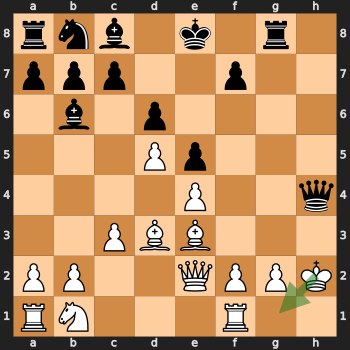

**Liubarski – Soultanbeieff** (Liege, 1928.??.??) — **White plays Kg1** — ✓ Engine best

**FEN:** `rnb1k1r1/ppp2p2/1b1p4/3Pp3/4P2q/2PBB3/PP2QPPK/RN3R2 w q - 1 16`

### Chernev's Annotation
> White’s only move.

### Stockfish Analysis (depth 22)
1. **Kg1** (eval M-7): Kg1 Qh3 Bb5+ c6 Qg4 Rxg4 g3 Bxe3 ← played

### Structured Template
```
{
  "include": true,
  "book_commentary": "White\u2019s only move.",
  "quality": "good",
  "reasoning": [
    "Kg1 is White's only legal king move."
  ]
}
```

---

In [97]:
entry = find_entry(optimal_moves,
    'rnb1k1r1/ppp2p2/1b1p4/3Pp3/4P2q/2PBB3/PP2QPPK/RN3R2 w q - 1 16',
    'h2g1')

engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])

template = json.dumps({
    "include": True,
    "book_commentary": entry['annotation'],
    "quality": "good",
    "reasoning": [
        "Kg1 is White's only legal king move."
    ]
}, indent=2)

show_example(entry, engine_lines, template)

---
## Example 2: d5 (good)
### Spielmann – Wahle (1926), Move 2: ...d5

Brief opening annotation — two atomic facts from Chernev.

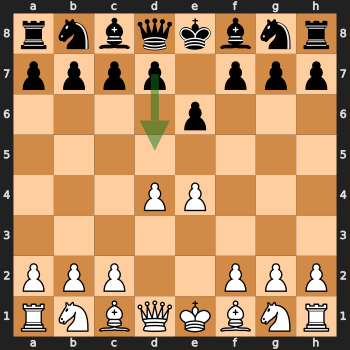

**Spielmann – Wahle** (Vienna, 1926.??.??) — **Black plays d5** — ✓ Engine best

**FEN:** `rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBNR b KQkq - 0 2`

### Chernev's Annotation
> Black gives his queen more scope and challenges the centre.

### Stockfish Analysis (depth 22)
1. **d5** (eval +0.32): d5 Nc3 Nf6 Bg5 dxe4 Nxe4 Be7 Bxf6 ← played
2. **a6** (eval +0.62): a6 Nc3 d5 Nf3 Nf6 e5 Nfd7 Ne2
3. **Be7** (eval +0.77): Be7 Bd3 d5 e5 c5 c3 Nc6 Nf3

### Structured Template
```
{
  "include": true,
  "book_commentary": "Black gives his queen more scope and challenges the centre.",
  "quality": "good",
  "reasoning": [
    "d5 challenges White's central pawn on e4.",
    "Opens a diagonal for Black's queen."
  ]
}
```

---

In [98]:
entry = find_entry(optimal_moves,
    'rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBNR b KQkq - 0 2',
    'd7d5')

engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])

template = json.dumps({
    "include": True,
    "book_commentary": entry['annotation'],
    "quality": "good",
    "reasoning": [
        "d5 challenges White's central pawn on e4.",
        "Opens a diagonal for Black's queen."
    ]
}, indent=2)

show_example(entry, engine_lines, template)

---
## Example 3: b4 (good)
### Noteboom – Doesburgh (1931), Move 19: b4

Positional move — Chernev's annotation is brief but the reasoning is concrete:
fixing the b5-pawn and preventing ...c5.

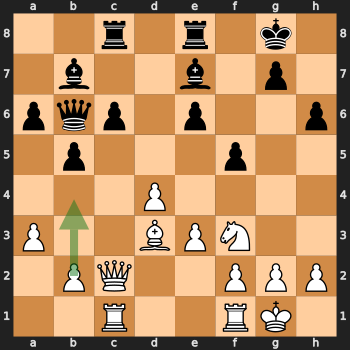

**Noteboom – Doesburgh** (Holland, 1931.??.??) — **White plays b4** — ✓ Engine best

**FEN:** `2r1r1k1/1b2b1p1/pqp1p2p/1p3p2/3P4/P2BPN2/1PQ2PPP/2R2RK1 w - - 4 19`

### Chernev's Annotation
> White nails the pawn down! White has a won game, strategically. What remains is to apply the proper tactical touches to compel the opponent to yield. The time is ripe for the combinations to appear!

### Stockfish Analysis (depth 22)
1. **b4** (eval +1.70): b4 Qd8 Rfe1 Bf6 Qb3 Qd5 Qb1 Qd8 ← played
2. **Qb3** (eval +0.46): Qb3 c5 dxc5 Bxc5 Bxf5 Bd5 Qd3 Bc4
3. **Qe2** (eval -0.12): Qe2 c5 dxc5 Rxc5 e4 Qc6 Rxc5 Bxc5

### Structured Template
```
{
  "include": true,
  "book_commentary": "White nails the pawn down! White has a won game, strategically. What remains is to apply the proper tactical touches to compel the opponent to yield. The time is ripe for the combinations to appear!",
  "quality": "good",
  "reasoning": [
    "b4 fixes the b5-pawn in place by blocking it.",
    "Prevents Black's only freeing break ...c5 \u2014 c5 is controlled by both the b4- and d4-pawns."
  ]
}
```

---

In [99]:
entry = find_entry(optimal_moves,
    '2r1r1k1/1b2b1p1/pqp1p2p/1p3p2/3P4/P2BPN2/1PQ2PPP/2R2RK1 w - - 4 19',
    'b2b4')

engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])

template = json.dumps({
    "include": True,
    "book_commentary": entry['annotation'],
    "quality": "good",
    "reasoning": [
        "b4 fixes the b5-pawn in place by blocking it.",
        "Prevents Black's only freeing break ...c5 \u2014 c5 is controlled by both the b4- and d4-pawns."
    ]
}, indent=2)

show_example(entry, engine_lines, template)

---
## Example 4: Qh6 (good)
### Tarrasch – Mieses (1916), Move 18: Qh6

Rich annotation — Chernev gives a mating line, a failed alternative, and explains
why the quiet move is stronger than the obvious check.

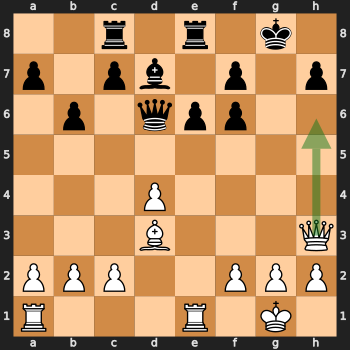

**Tarrasch – Mieses** (Berlin, 1916.??.??) — **White plays Qh6** — ✓ Engine best

**FEN:** `2r1r1k1/p1pb1p1p/1p1qpp2/8/3P4/3B3Q/PPP2PPP/R3R1K1 w - - 0 18`

### Chernev's Annotation
> Holding the king fast! The idea is to keep him from escaping by way of f8 while facing him with deadly threats. The modus operandi after the text-move is 19 Bxh7+! Kh8 20 Bg6+ Kg8 21 Qh7+ Kf8 22 Qxf7#.
If you can play this sort of move (18 Qh6), you are a cut above the average player. Most young players (in a chess sense) have a tendency to try checking the king to death only to find after something like 18 Qxh7+ Kf8 19 Qh8+ Ke7 that the king has escaped and the attack is exhausted. What is worse is that White’s queen and d-pawn are threatened, and that saving both by 20 Qh4 lets Black respond with 20... Rh8 and suddenly White is thrown on the defensive!

### Stockfish Analysis (depth 22)
1. **Qh6** (eval +5.61): Qh6 f5 Re3 f6 Rg3+ Qxg3 hxg3 c5 ← played
2. **Re3** (eval +3.66): Re3 Kf8 Qh4 f5 Rd1 Bc6 Qh6+ Ke7
3. **Qh4** (eval +3.65): Qh4 f5 Re3 Kf8 Rd1 Bc6 Qh6+ Ke7

### Structured Template
```
{
  "include": true,
  "book_commentary": "Holding the king fast! The idea is to keep him from escaping by way of f8 while facing him with deadly threats. The modus operandi after the text-move is 19 Bxh7+! Kh8 20 Bg6+ Kg8 21 Qh7+ Kf8 22 Qxf7#.\nIf you can play this sort of move (18 Qh6), you are a cut above the average player. Most young players (in a chess sense) have a tendency to try checking the king to death only to find after something like 18 Qxh7+ Kf8 19 Qh8+ Ke7 that the king has escaped and the attack is exhausted. What is worse is that White\u2019s queen and d-pawn are threatened, and that saving both by 20 Qh4 lets Black respond with 20... Rh8 and suddenly White is thrown on the defensive!",
  "quality": "good",
  "reasoning": [
    "Qh6 prevents the king from escaping via f8.",
    "The Bd3 aims at h7 along the b1-h7 diagonal.",
    "Sets up a forced mating sequence."
  ],
  "variation": "19.Bxh7+ Kh8 20.Bg6+ Kg8 21.Qh7+ Kf8 22.Qxf7#",
  "alternative": {
    "move": "Qxh7+",
    "reasoning": [
      "After 18.Qxh7+ Kf8 19.Qh8+ Ke7, the king escapes and the attack is exhausted. White's queen and d-pawn are both threatened; 20.Qh4 Rh8 throws White on the defensive."
    ]
  }
}
```

---

In [100]:
entry = find_entry(optimal_moves,
    '2r1r1k1/p1pb1p1p/1p1qpp2/8/3P4/3B3Q/PPP2PPP/R3R1K1 w - - 0 18',
    'h3h6')

engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])

template = json.dumps({
    "include": True,
    "book_commentary": entry['annotation'],
    "quality": "good",
    "reasoning": [
        "Qh6 prevents the king from escaping via f8.",
        "The Bd3 aims at h7 along the b1-h7 diagonal.",
        "Sets up a forced mating sequence."
    ],
    "variation": "19.Bxh7+ Kh8 20.Bg6+ Kg8 21.Qh7+ Kf8 22.Qxf7#",
    "alternative": {
        "move": "Qxh7+",
        "reasoning": [
            "After 18.Qxh7+ Kf8 19.Qh8+ Ke7, the king escapes and the attack is exhausted. White's queen and d-pawn are both threatened; 20.Qh4 Rh8 throws White on the defensive."
        ]
    }
}, indent=2)

show_example(entry, engine_lines, template)

---
## Example 5: f4 (good)
### Pillsbury – Marco (1900), Move 10: f4

Strategic annotation — Chernev explains pawn support, exchange consequences,
and the resulting f-file attack.

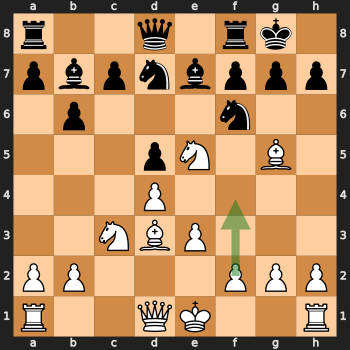

**Pillsbury – Marco** (Paris, 1900.??.??) — **White plays f4** — ✓ Engine best

**FEN:** `r2q1rk1/pbpnbppp/1p3n2/3pN1B1/3P4/2NBP3/PP3PPP/R2QK2R w KQ - 2 10`

### Chernev's Annotation
> This pawn not only strengthens the position of the knight by providing it with a firm base, but it discourages Black from exchanging pieces. On 10... Nxe5, the recapture by 11 fxe5 opens wide the f-file for an attack by the heavy pieces. The capturing pawn itself will then stab at Black’s f6-knight and drive it away from its strong defensive post.

### Stockfish Analysis (depth 22)
1. **Qc2** (eval +0.39): Qc2 c5 O-O h6 Bh4 Nxe5 dxe5 Nd7
2. **f4** (eval +0.39): f4 Ne4 Bxe7 Qxe7 O-O Rad8 Qc2 Ndf6 ← played
3. **Bf4** (eval +0.38): Bf4 Nxe5 dxe5 Ne4 Qc2 Nxc3 bxc3 h6

### Structured Template
```
{
  "include": true,
  "book_commentary": "This pawn not only strengthens the position of the knight by providing it with a firm base, but it discourages Black from exchanging pieces. On 10... Nxe5, the recapture by 11 fxe5 opens wide the f-file for an attack by the heavy pieces. The capturing pawn itself will then stab at Black\u2019s f6-knight and drive it away from its strong defensive post.",
  "quality": "good",
  "reasoning": [
    "f4 gives the Ne5 a firm pawn base.",
    "Discourages Black from exchanging: after 10...Nxe5 11.fxe5, the f-file opens for White's heavy pieces and the e5-pawn attacks the Nf6, driving it from its defensive post."
  ],
  "variation": "10...Nxe5 11.fxe5"
}
```

---

In [101]:
entry = find_entry(optimal_moves,
    'r2q1rk1/pbpnbppp/1p3n2/3pN1B1/3P4/2NBP3/PP3PPP/R2QK2R w KQ - 2 10',
    'f2f4')

engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])

template = json.dumps({
    "include": True,
    "book_commentary": entry['annotation'],
    "quality": "good",
    "reasoning": [
        "f4 gives the Ne5 a firm pawn base.",
        "Discourages Black from exchanging: after 10...Nxe5 11.fxe5, the f-file opens for White's heavy pieces and the e5-pawn attacks the Nf6, driving it from its defensive post."
    ],
    "variation": "10...Nxe5 11.fxe5"
}, indent=2)

show_example(entry, engine_lines, template)

---
## Example 6: O-O (mistake)
### Blackburne – Blanchard (1891), Move 12: ...O-O

Mistake — most of Chernev's annotation explains the better alternative Na5.
The alternative field gets full atomic treatment.

In [ ]:
entry = find_entry(other_moves,
    'r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12',
    'e8g8')

engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])

template = json.dumps({
    "include": True,
    "book_commentary": entry['annotation'],
    "quality": "mistake",
    "reasoning": [
        "Castles into White's prepared kingside attack.",
        "White's one weakness is the doubled c-pawns \u2014 Black should be exploiting that instead."
    ],
    "alternative": {
        "move": "Na5",
        "reasoning": [
            "Reroutes the knight toward c4, where it blockades the doubled c-pawn.",
            "Interferes with the free movement of White's pieces.",
            "If White captures (Bxc4 dxc4), White's pawn structure becomes inferior to Black's.",
            "Black can anchor a piece on d5, which cannot be evicted by pawns."
        ]
    }
}, indent=2)

show_example(entry, engine_lines, template, is_bad_move=True)

---
# Part 2: Gold Extraction — API Template + Candidate Positions

The LLM is given FEN + move + engine lines + **book commentary** and must
extract a structured template. This is a commentary extraction/structuring problem.

In [ ]:
import math

K = 0.00368208

def cp_to_winpct(cp):
    """Lichess win% formula."""
    return 50 + 50 * math.tanh(K * cp / 2)


# ── Hand-written gold templates (explicit JSON strings) ───────────────────
# __COMMENTARY__ is replaced with json.dumps(entry['annotation']) at build time.

DEMO_TEMPLATES = [
    # Example 1: Kg1 (good, minimal) — INCLUDE
    '{\n'
    '  "include": true,\n'
    '  "book_commentary": __COMMENTARY__,\n'
    '  "quality": "good",\n'
    '  "reasoning": [\n'
    '    "Kg1 is White\'s only legal king move."\n'
    '  ]\n'
    '}',

    # Example 2: Qh6 (good, rich — variation + alternative from commentary) — INCLUDE
    '{\n'
    '  "include": true,\n'
    '  "book_commentary": __COMMENTARY__,\n'
    '  "quality": "good",\n'
    '  "reasoning": [\n'
    '    "Qh6 prevents the king from escaping via f8.",\n'
    '    "The Bd3 aims at h7 along the b1-h7 diagonal.",\n'
    '    "Sets up a forced mating sequence."\n'
    '  ],\n'
    '  "variation": "19.Bxh7+ Kh8 20.Bg6+ Kg8 21.Qh7+ Kf8 22.Qxf7#",\n'
    '  "alternative": {\n'
    '    "move": "Qxh7+",\n'
    '    "reasoning": [\n'
    '      "After 18.Qxh7+ Kf8 19.Qh8+ Ke7, the king escapes and the attack is exhausted. White\'s queen and d-pawn are both threatened"\n'
    '    ]\n'
    '  }\n'
    '}',

    # Example 3: f4 (good, strategic — grouped atoms) — INCLUDE
    '{\n'
    '  "include": true,\n'
    '  "book_commentary": __COMMENTARY__,\n'
    '  "quality": "good",\n'
    '  "reasoning": [\n'
    '    "f4 gives the Ne5 a firm pawn base.",\n'
    '    "Discourages Black from exchanging: after 10...Nxe5 11.fxe5, the f-file opens for White\'s heavy pieces and the e5-pawn attacks the Nf6, driving it from its defensive post."\n'
    '  ],\n'
    '  "variation": "10...Nxe5 11.fxe5"\n'
    '}',

    # Example 4: O-O (mistake, wp_loss=24.1% — alternative with full treatment from commentary) — INCLUDE
    '{\n'
    '  "include": true,\n'
    '  "book_commentary": __COMMENTARY__,\n'
    '  "quality": "mistake",\n'
    '  "reasoning": [\n'
    '    "Castles into White\'s prepared kingside attack.",\n'
    '    "White\'s one weakness is the doubled c-pawns \\u2014 Black should be exploiting that instead."\n'
    '  ],\n'
    '  "alternative": {\n'
    '    "move": "Na5",\n'
    '    "reasoning": [\n'
    '      "Reroutes the knight toward c4, where it blockades the doubled c-pawn.",\n'
    '      "Interferes with the free movement of White\'s pieces.",\n'
    '      "If White captures (Bxc4 dxc4), White\'s pawn structure becomes inferior to Black\'s.",\n'
    '      "Black can anchor a piece on d5, which cannot be evicted by pawns."\n'
    '    ]\n'
    '  }\n'
    '}',

    # Example 5: g6 (good by engine, 8.4% wp_loss) — EXCLUDE
    # Commentary contains generic philosophy not specific to position.
    '{\n'
    '  "include": false,\n'
    '  "exclude_reason": "contains generic chess philosophy not specific to position",\n'
    '  "book_commentary": __COMMENTARY__\n'
    '}',

    # Example 6: Nd3 (mistake, 20.3% wp_loss) — EXCLUDE
    # Commentary praises a mistake with no discussion of why it fails.
    '{\n'
    '  "include": false,\n'
    '  "exclude_reason": "commentary praises move but wp_loss=20.3% indicates mistake; no discussion of why the move fails",\n'
    '  "book_commentary": __COMMENTARY__\n'
    '}',
]

# Demo positions: (fen, move_uci) — dataset searched automatically
DEMO_POSITIONS = [
    ('rnb1k1r1/ppp2p2/1b1p4/3Pp3/4P2q/2PBB3/PP2QPPK/RN3R2 w q - 1 16', 'h2g1'),
    ('2r1r1k1/p1pb1p1p/1p1qpp2/8/3P4/3B3Q/PPP2PPP/R3R1K1 w - - 0 18', 'h3h6'),
    ('r2q1rk1/pbpnbppp/1p3n2/3pN1B1/3P4/2NBP3/PP3PPP/R2QK2R w KQ - 2 10', 'f2f4'),
    ('r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12', 'e8g8'),
    ('r3nrk1/2qbbppp/p1np4/1pp1p3/3PP3/2P1BN1P/PPB2PP1/2RQRNK1 b - - 8 15', 'g7g6'),
    ('6k1/5p1p/5p2/2NB4/p1Pp4/6P1/4KP1P/r7 w - - 2 32', 'c5d3'),
]

# ── System prompt for GOLD EXTRACTION ─────────────────────────────────────

SYSTEM_PROMPT = """\
You are extracting structured move explanations from chess book commentary.

You will receive: a FEN, the move played, engine analysis, and the book's
commentary for that move. Your job is to EXTRACT and STRUCTURE the commentary
into a JSON object.

Output ONLY valid JSON. No preamble, no markdown fences, no explanation.

When include=true, output:
{
  "include": true,
  "book_commentary": "<the full original commentary>",
  "quality": "good | inaccuracy | mistake | blunder",
  "reasoning": ["atomic fact 1", "atomic fact 2"],
  "variation": "19.Bxh7+ Kh8 20.Bg6+ ...",          // optional
  "alternative": {                                     // optional
    "move": "Qxh7+",
    "reasoning": ["why it's worse/better"],
    "variation": "18.Qxh7+ Kf8 ..."                   // optional
  }
}

When include=false, output ONLY:
{
  "include": false,
  "exclude_reason": "short explanation",
  "book_commentary": "<the full original commentary>"
}

Quality classification (use the engine data provided):
  good       -> wp_loss <= 10%
  inaccuracy -> wp_loss > 10%
  mistake    -> wp_loss > 20%
  blunder    -> wp_loss > 30%

CRITICAL RULES:

1. EXTRACTION ONLY. Extract information present in the commentary.
   Do NOT invent strategic claims the author did not make.
   Do NOT add alternative moves not discussed in the commentary.

2. Board-verifiable enrichment is OK: piece locations, whether a move
   gives check, whether a square is controlled. Use tools to verify.

3. ATOM GROUPING. Each reasoning item = one atomic fact. Group logically
   connected setup+consequence into a SINGLE atom. If two sentences
   express the same idea, combine them into one atom.

4. Reasoning atoms capture the CONCLUSION of a variation ("White wins a rook", "the attack is exhausted"), not individual sub-lines within it. Detailed move sequences
  belong in the variation field. Do not split a variation's internal justifications into separate atoms.

5. Name squares, pieces, and diagonals concretely.

6. INCLUDE/EXCLUDE. Set "include": false when:
   - Commentary praises or describes a move positively but the engine
     shows it is an inaccuracy, mistake, or blunder (wp_loss > 10%).
     This is a quality/engine conflict — the commentary's positive
     claims cannot be trusted.
   - Commentary does not explain WHY an inaccuracy/mistake/blunder move
     is bad. If the commentary only says positive things about a
     suboptimal move, exclude.
   - Commentary is purely historical anecdotes, player biographies,
     or tournament/venue details with no move-specific analysis.
   - Commentary is generic chess philosophy not applied to this position
     (e.g. "recognizing weaknesses marks the master player").
   - Commentary contains only raw notation without strategic explanation.
   - Commentary is too minimal to extract any meaningful atom.
   When "include": false, output ONLY include, exclude_reason, and
   book_commentary. Do NOT output quality, reasoning, or other fields.

7. NEVER include generic philosophical statements as atoms. Statements
   like "good players exploit weaknesses" or "a tribute to the power of
   passed pawns" are not position-specific and must be excluded from
   reasoning lists. If the commentary is MOSTLY generic philosophy,
   set include=false.

8. If the move captures with check, call it a "capture" or "check",
   not a "sacrifice".

9. Depth matches the commentary's richness, NOT an imposed judgment.

10. For inaccuracy/mistake/blunder: reasoning = why this move fails
   (from commentary); alternative = the better move with full atomic
   treatment (from commentary). If the commentary does not discuss an
   alternative, omit the field entirely. If the commentary does not
   explain WHY the move is bad, set include=false.

Available tools (use to verify board claims, NOT to generate new content):
  get_attacks(fen, square)    - squares attacked by the piece on that square
  get_attackers(fen, sq, col) - pieces of a color attacking a square
  get_legal_moves(fen)        - all legal moves
  is_pinned(fen, square)      - is a piece pinned to its king?
  is_check(fen)               - is the side to move in check?
  try_variation(fen, moves)   - verify a move sequence is legal + get eval
  compare_moves(fen, a, b)    - compare eval of two moves
  make_move(fen, move)        - get FEN after a move + check status
  get_piece_at(fen, square)   - what piece is on a square
  get_engine_eval(fen)        - Stockfish eval + best move
"""


def build_user_prompt(entry, engine_lines):
    """Build the user prompt for gold extraction: FEN + move + engine + commentary."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))

    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    played_line = next((l for l in engine_lines if not l.get('is_top', True)), None)

    pv_text = []
    for i, line in enumerate(top_lines, 1):
        pv_text.append(f"  {i}. {line['move_san']} ({line['eval']}): {line['pv_san']}")

    wp_loss = entry.get('wp_loss', 0)
    if wp_loss > 30:
        quality_hint = f" [BLUNDER — wp_loss: {wp_loss:.1f}%]"
    elif wp_loss > 20:
        quality_hint = f" [MISTAKE — wp_loss: {wp_loss:.1f}%]"
    elif wp_loss > 10:
        quality_hint = f" [INACCURACY — wp_loss: {wp_loss:.1f}%]"
    else:
        quality_hint = f" [wp_loss: {wp_loss:.1f}%]"

    prompt = (
        f"FEN: {entry['fen']}\n"
        f"Move played: {move_san}{quality_hint}\n"
        f"Engine top-3:\n" + "\n".join(pv_text) + "\n"
    )

    if played_line:
        prompt += (
            f"Played move eval:\n"
            f"  {played_line['move_san']} ({played_line['eval']}): {played_line['pv_san']}\n"
        )

    prompt += f"\nCommentary: \"{entry['annotation']}\"\n"
    return prompt


# ── Post-processing filter ────────────────────────────────────────────────

def postprocess_filter(entry, parsed_json):
    """Apply post-processing filters that catch what the LLM might miss.
    
    Returns (include, exclude_reason) — overrides LLM's include flag if needed.
    """
    wp_loss = entry.get('wp_loss', 0)
    quality = parsed_json.get('quality', 'good')
    
    # Commentary says good but engine disagrees significantly
    if quality == 'good' and wp_loss > 10:
        return False, f"quality/engine conflict: commentary says good but wp_loss={wp_loss:.1f}%"
    
    # Commentary says non-good but engine says it's fine
    if quality in ('inaccuracy', 'mistake', 'blunder') and wp_loss < 2:
        return False, f"quality/engine conflict: commentary says {quality} but wp_loss={wp_loss:.1f}%"
    
    # Alternative present but no reasoning (hallucinated)
    alt = parsed_json.get('alternative')
    if alt and not alt.get('reasoning'):
        return False, "alternative has no reasoning — likely not from commentary"
    
    # No reasoning atoms at all (for included entries)
    if parsed_json.get('include', True) and not parsed_json.get('reasoning'):
        return False, "no reasoning atoms extracted"
    
    return parsed_json.get('include', True), parsed_json.get('exclude_reason')


# ── Build DEMOS programmatically with live Stockfish analysis ─────────

def find_entry_any(fen, move_uci):
    """Search both optimal and other moves datasets."""
    for e in optimal_moves + other_moves:
        if e['fen'] == fen and e['move_uci'] == move_uci:
            return e
    raise ValueError(f'Entry not found: {fen} {move_uci}')

print("Building few-shot demos with live Stockfish analysis...")

DEMOS = []
for (fen, move_uci), template_str in zip(DEMO_POSITIONS, DEMO_TEMPLATES):
    entry = find_entry_any(fen, move_uci)
    el = get_engine_analysis(entry['fen'], entry['move_uci'])
    user_prompt = build_user_prompt(entry, el)

    # Inject book_commentary from entry
    assistant_text = template_str.replace('__COMMENTARY__', json.dumps(entry['annotation']))

    DEMOS.append({"role": "user", "content": user_prompt})
    DEMOS.append({"role": "assistant", "content": assistant_text})

    board = chess.Board(fen)
    san = board.san(chess.Move.from_uci(move_uci))
    is_exclude = '"include": false' in template_str
    inc_tag = "EXCLUDE" if is_exclude else "INCLUDE"
    print(f"  {san} [{inc_tag}]: done")

print(f"\nGold extraction template ready.")
print(f"  DEMOS: {len(DEMOS)} messages ({len(DEMOS)//2} examples)")
print(f"  SYSTEM_PROMPT: {len(SYSTEM_PROMPT)} chars")
print(f"\nSample INCLUDE response (first demo):")
print(DEMOS[1]["content"])
print(f"\nSample EXCLUDE response (5th demo):")
print(DEMOS[9]["content"])

In [104]:
# ── Chess Tool Functions ──────────────────────────────────────────────────
# Each function takes simple args, returns a compact JSON string.

import json as _json

def tool_get_legal_moves(fen):
    """All legal moves in SAN."""
    board = chess.Board(fen)
    moves = [board.san(m) for m in board.legal_moves]
    return _json.dumps({"moves": moves, "count": len(moves)})

def tool_get_piece_at(fen, square):
    """What piece is on a square."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"square": square, "piece": "empty"})
    color = "white" if p.color == chess.WHITE else "black"
    name = chess.piece_name(p.piece_type)
    return _json.dumps({"square": square, "piece": f"{color} {name}"})

def tool_get_attacks(fen, square):
    """Squares attacked by the piece on a given square."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    attacks = sorted([chess.square_name(a) for a in board.attacks(sq)])
    return _json.dumps({"piece": p.symbol(), "square": square, "attacks": attacks})

def tool_get_attackers(fen, square, color):
    """Which pieces of a given color attack a square."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    c = chess.WHITE if color == "white" else chess.BLACK
    attackers = []
    for a in board.attackers(c, sq):
        p = board.piece_at(a)
        attackers.append([chess.piece_name(p.piece_type), chess.square_name(a)])
    return _json.dumps({"square": square, "color": color, "attackers": attackers})

def tool_is_pinned(fen, square):
    """Check if a piece is pinned."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    pinned = board.is_pinned(p.color, sq)
    result = {"square": square, "pinned": pinned}
    if pinned:
        pin_mask = board.pin(p.color, sq)
        result["pin_ray"] = str(chess.SquareSet(pin_mask))
    return _json.dumps(result)

def tool_is_check(fen):
    """Is the side to move in check?"""
    board = chess.Board(fen)
    in_check = board.is_check()
    result = {"in_check": in_check}
    if in_check:
        checkers = [chess.square_name(sq) for sq in board.checkers()]
        result["checkers"] = checkers
    return _json.dumps(result)

def tool_try_variation(fen, moves):
    """Try a sequence of SAN moves. Returns legality + final eval."""
    board = chess.Board(fen)
    played = []
    for san in moves:
        try:
            move = board.parse_san(san)
            played.append(board.san(move))
            board.push(move)
        except Exception as e:
            return _json.dumps({"legal": False, "error": f"{san}: {str(e)}", "played": played})
    result = {"legal": True, "played": played}
    if board.is_checkmate():
        result["eval"] = "checkmate"
    elif board.is_stalemate():
        result["eval"] = "stalemate"
    else:
        with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
            info = engine.analyse(board, chess.engine.Limit(depth=18))
            sc = info['score'].white()
            mate = sc.mate()
            result["eval"] = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
    return _json.dumps(result)

def tool_get_engine_eval(fen, depth=20):
    """Stockfish eval + best move."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        sc = info['score'].white()
        pv = info.get('pv', [])
        mate = sc.mate()
        ev = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
        best = board.san(pv[0]) if pv else "?"
    return _json.dumps({"eval": ev, "best_move": best})

def tool_compare_moves(fen, move_a, move_b, depth=20):
    """Compare two moves: eval + win% difference."""
    board = chess.Board(fen)
    K = 0.00368208
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        # Eval after move_a
        ba = board.copy()
        ba.push(board.parse_san(move_a))
        ia = engine.analyse(ba, chess.engine.Limit(depth=int(depth)))
        sa = ia['score'].white().score(mate_score=10000)
        # Eval after move_b
        bb = board.copy()
        bb.push(board.parse_san(move_b))
        ib = engine.analyse(bb, chess.engine.Limit(depth=int(depth)))
        sb = ib['score'].white().score(mate_score=10000)
    sign = 1 if board.turn == chess.WHITE else -1
    wp_diff = abs(wp(sa) - wp(sb))
    return _json.dumps({
        "move_a": move_a, "eval_a": f"{sa/100:+.2f}",
        "move_b": move_b, "eval_b": f"{sb/100:+.2f}",
        "wp_diff": round(wp_diff, 1)
    })

def tool_make_move(fen, move):
    """Make a move, return new FEN and whether it gives check."""
    board = chess.Board(fen)
    m = board.parse_san(move)
    gives_check = board.gives_check(m)
    board.push(m)
    return _json.dumps({"fen": board.fen(), "gives_check": gives_check})

# ── Dispatch + Schemas ────────────────────────────────────────────────────

TOOL_FUNCTIONS = {
    "get_legal_moves": tool_get_legal_moves,
    "get_piece_at": tool_get_piece_at,
    "get_attacks": tool_get_attacks,
    "get_attackers": tool_get_attackers,
    "is_pinned": tool_is_pinned,
    "is_check": tool_is_check,
    "try_variation": tool_try_variation,
    "get_engine_eval": tool_get_engine_eval,
    "compare_moves": tool_compare_moves,
    "make_move": tool_make_move,
}

def _schema(name, desc, props, required):
    """Helper to build OpenAI-format tool schema."""
    return {
        "type": "function",
        "function": {
            "name": name,
            "description": desc,
            "parameters": {
                "type": "object",
                "properties": props,
                "required": required,
            }
        }
    }

_fen_prop = {"fen": {"type": "string", "description": "FEN of the position"}}
_sq_prop = {"square": {"type": "string", "description": "Square name, e.g. 'd3'"}}

TOOL_SCHEMAS_OPENAI = [
    _schema("get_legal_moves", "Get all legal moves in SAN notation.",
            _fen_prop, ["fen"]),
    _schema("get_piece_at", "Get the piece on a square (or 'empty').",
            {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attacks", "Get all squares attacked by the piece on a square.",
            {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attackers", "Get all pieces of a color that attack a square.",
            {**_fen_prop, **_sq_prop,
             "color": {"type": "string", "enum": ["white", "black"]}},
            ["fen", "square", "color"]),
    _schema("is_pinned", "Check if a piece is absolutely pinned to its king.",
            {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("is_check", "Check if the side to move is in check.",
            _fen_prop, ["fen"]),
    _schema("try_variation", "Try a sequence of SAN moves. Returns legality and final eval.",
            {**_fen_prop,
             "moves": {"type": "array", "items": {"type": "string"},
                       "description": "List of SAN moves, e.g. ['Bxh7+','Kh8','Bg6+']"}},
            ["fen", "moves"]),
    _schema("get_engine_eval", "Get Stockfish evaluation and best move.",
            {**_fen_prop,
             "depth": {"type": "integer", "description": "Search depth (default 20)"}},
            ["fen"]),
    _schema("compare_moves", "Compare eval of two moves. Returns evals and win% difference.",
            {**_fen_prop,
             "move_a": {"type": "string", "description": "First move in SAN"},
             "move_b": {"type": "string", "description": "Second move in SAN"},
             "depth": {"type": "integer", "description": "Search depth (default 20)"}},
            ["fen", "move_a", "move_b"]),
    _schema("make_move", "Make a move and return the resulting FEN.",
            {**_fen_prop,
             "move": {"type": "string", "description": "Move in SAN notation"}},
            ["fen", "move"]),
]

# Anthropic format
TOOL_SCHEMAS_ANTHROPIC = []
for s in TOOL_SCHEMAS_OPENAI:
    TOOL_SCHEMAS_ANTHROPIC.append({
        "name": s["function"]["name"],
        "description": s["function"]["description"],
        "input_schema": s["function"]["parameters"],
    })

def execute_tool(name, arguments):
    """Execute a tool by name with given arguments."""
    fn = TOOL_FUNCTIONS.get(name)
    if fn is None:
        return _json.dumps({"error": f"unknown tool: {name}"})
    try:
        return fn(**arguments)
    except Exception as e:
        return _json.dumps({"error": str(e)})

# Quick test
print("Tools defined:", list(TOOL_FUNCTIONS.keys()))
print(f"  OpenAI schemas: {len(TOOL_SCHEMAS_OPENAI)}")
print(f"  Anthropic schemas: {len(TOOL_SCHEMAS_ANTHROPIC)}")
print("\nTest get_attacks('rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1', 'e4'):")
print(" ", tool_get_attacks('rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1', 'e4'))

Tools defined: ['get_legal_moves', 'get_piece_at', 'get_attacks', 'get_attackers', 'is_pinned', 'is_check', 'try_variation', 'get_engine_eval', 'compare_moves', 'make_move']
  OpenAI schemas: 10
  Anthropic schemas: 10

Test get_attacks('rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1', 'e4'):
  {"piece": "P", "square": "e4", "attacks": ["d5", "f5"]}


In [105]:
# ── API Abstraction: OpenAI / Anthropic ───────────────────────────────────

from dotenv import load_dotenv
load_dotenv()
from dataclasses import dataclass, field

@dataclass
class ToolCall:
    id: str
    name: str
    arguments: dict

@dataclass
class LLMResponse:
    text: str  # final text content (may be empty if tool calls)
    tool_calls: list  # list of ToolCall


def call_openai(messages, tools=None, model="gpt-4o", temperature=0.3):
    """Call OpenAI API with optional tool use."""
    import openai
    client = openai.OpenAI()
    kwargs = dict(model=model, messages=messages, temperature=temperature, max_tokens=2048)
    if tools:
        kwargs["tools"] = tools
        kwargs["tool_choice"] = "auto"
    resp = client.chat.completions.create(**kwargs)
    msg = resp.choices[0].message
    text = msg.content or ""
    tc = []
    if msg.tool_calls:
        for c in msg.tool_calls:
            tc.append(ToolCall(
                id=c.id,
                name=c.function.name,
                arguments=_json.loads(c.function.arguments),
            ))
    return LLMResponse(text=text, tool_calls=tc), msg


def call_anthropic(messages, tools=None, model="claude-sonnet-4-5-20250929",
                   system=None, temperature=0.3):
    """Call Anthropic API with optional tool use."""
    import anthropic
    client = anthropic.Anthropic()
    kwargs = dict(model=model, max_tokens=2048, temperature=temperature)
    if system:
        kwargs["system"] = system
    # Convert messages: strip system from messages list (Anthropic uses separate param)
    api_messages = [m for m in messages if m["role"] != "system"]
    kwargs["messages"] = api_messages
    if tools:
        kwargs["tools"] = tools
    resp = client.messages.create(**kwargs)
    text = ""
    tc = []
    for block in resp.content:
        if block.type == "text":
            text += block.text
        elif block.type == "tool_use":
            tc.append(ToolCall(id=block.id, name=block.name, arguments=block.input))
    return LLMResponse(text=text, tool_calls=tc), resp


def call_llm(messages, tools=None, provider="openai", model=None, temperature=0.3):
    """Unified LLM call. Returns (LLMResponse, raw_response)."""
    if provider == "openai":
        m = model or "gpt-4o"
        return call_openai(messages, tools=tools, model=m, temperature=temperature)
    elif provider == "anthropic":
        m = model or "claude-sonnet-4-5-20250929"
        sys_msg = next((msg["content"] for msg in messages if msg["role"] == "system"), None)
        return call_anthropic(messages, tools=tools, model=m, system=sys_msg,
                              temperature=temperature)
    else:
        raise ValueError(f"Unknown provider: {provider}")


def append_tool_result_openai(messages, raw_msg, tool_call, result_str):
    """Append tool call + result to OpenAI message list."""
    # The assistant message with tool_calls should already be in messages
    messages.append({
        "role": "tool",
        "tool_call_id": tool_call.id,
        "content": result_str,
    })

def append_tool_result_anthropic(messages, tool_call, result_str):
    """Append tool result to Anthropic message list."""
    messages.append({
        "role": "user",
        "content": [{"type": "tool_result", "tool_use_id": tool_call.id, "content": result_str}],
    })


print("API abstraction ready. Providers: openai, anthropic")

API abstraction ready. Providers: openai, anthropic


In [ ]:
# ── Programmatic candidate selection ──────────────────────────────────────
# Goal: pick ~20 diverse candidates across quality levels, game phases,
# annotation lengths. Exclude the demo FENs (including exclude demos).

import random
random.seed(42)

DEMO_FENS = {
    'rnb1k1r1/ppp2p2/1b1p4/3Pp3/4P2q/2PBB3/PP2QPPK/RN3R2 w q - 1 16',
    'rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBNR b KQkq - 0 2',
    '2r1r1k1/1b2b1p1/pqp1p2p/1p3p2/3P4/P2BPN2/1PQ2PPP/2R2RK1 w - - 4 19',
    '2r1r1k1/p1pb1p1p/1p1qpp2/8/3P4/3B3Q/PPP2PPP/R3R1K1 w - - 0 18',
    'r2q1rk1/pbpnbppp/1p3n2/3pN1B1/3P4/2NBP3/PP3PPP/R2QK2R w KQ - 2 10',
    'r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12',
    'r3nrk1/2qbbppp/p1np4/1pp1p3/3PP3/2P1BN1P/PPB2PP1/2RQRNK1 b - - 8 15',  # g6 exclude demo
    '6k1/5p1p/5p2/2NB4/p1Pp4/6P1/4KP1P/r7 w - - 2 32',  # Nd3 exclude demo
}

def get_move_number(fen):
    """Extract full move number from FEN."""
    return int(fen.split()[-1])

def get_game_phase(move_num):
    if move_num <= 10: return 'opening'
    elif move_num <= 25: return 'middlegame'
    else: return 'endgame'

def classify_quality(entry):
    """Classify move quality from wp_loss."""
    wp = entry.get('wp_loss', 0)
    if wp > 30: return 'blunder'
    elif wp > 20: return 'mistake'
    elif wp > 10: return 'inaccuracy'
    else: return 'good'

def annotation_length(entry):
    return len(entry['annotation'].split())

# Classify all entries
all_entries = []
for e in optimal_moves:
    if e['fen'] not in DEMO_FENS:
        all_entries.append({
            'entry': e,
            'quality': classify_quality(e),
            'phase': get_game_phase(get_move_number(e['fen'])),
            'ann_len': annotation_length(e),
        })

for e in other_moves:
    if e['fen'] not in DEMO_FENS:
        all_entries.append({
            'entry': e,
            'quality': classify_quality(e),
            'phase': get_game_phase(get_move_number(e['fen'])),
            'ann_len': annotation_length(e),
        })

# Print distribution
from collections import Counter
qual_counts = Counter(c['quality'] for c in all_entries)
phase_counts = Counter(c['phase'] for c in all_entries)
print("All entries by quality:", dict(qual_counts))
print("All entries by game phase:", dict(phase_counts))

# ── Sample diverse candidates ────────────────────────────────────────────
# Strategy: stratify by quality × phase, also get range of annotation lengths

candidates = []

# Good moves: sample across phases and annotation lengths
good_pool = [c for c in all_entries if c['quality'] == 'good']
for phase in ['opening', 'middlegame', 'endgame']:
    phase_pool = [c for c in good_pool if c['phase'] == phase]
    if phase_pool:
        # Get one short annotation and one long annotation per phase
        phase_pool.sort(key=lambda c: c['ann_len'])
        short = [c for c in phase_pool if c['ann_len'] <= 15]
        long = [c for c in phase_pool if c['ann_len'] > 30]
        if short:
            candidates.append(random.choice(short))
        if long:
            candidates.append(random.choice(long))
        if not short and not long:
            candidates.append(random.choice(phase_pool))

# Inaccuracy moves: sample available
inaccuracy_pool = [c for c in all_entries if c['quality'] == 'inaccuracy']
candidates.extend(random.sample(inaccuracy_pool, min(3, len(inaccuracy_pool))))

# Mistake moves: sample available
mistake_pool = [c for c in all_entries if c['quality'] == 'mistake']
candidates.extend(random.sample(mistake_pool, min(3, len(mistake_pool))))

# Blunders: sample all available
blunder_pool = [c for c in all_entries if c['quality'] == 'blunder']
candidates.extend(random.sample(blunder_pool, min(3, len(blunder_pool))))

# Deduplicate by FEN
seen_fens = set()
unique_candidates = []
for c in candidates:
    fen = c['entry']['fen']
    if fen not in seen_fens:
        seen_fens.add(fen)
        unique_candidates.append(c)
candidates = unique_candidates

print(f"\nSelected {len(candidates)} candidates:")
print(f"  By quality: {dict(Counter(c['quality'] for c in candidates))}")
print(f"  By phase: {dict(Counter(c['phase'] for c in candidates))}")

# Show candidate table
print(f"\n{'#':>2} {'Quality':>10} {'Phase':>11} {'AnnLen':>6} {'WpLoss':>7} {'Move':>6} {'Game'}")
print('-' * 80)
for i, c in enumerate(candidates, 1):
    e = c['entry']
    board = chess.Board(e['fen'])
    san = board.san(chess.Move.from_uci(e['move_uci']))
    game = e['metadata'].get('White', '?') + '–' + e['metadata'].get('Black', '?')
    wp = e.get('wp_loss', 0)
    print(f"{i:>2} {c['quality']:>10} {c['phase']:>11} {c['ann_len']:>6} {wp:>6.1f}% {san:>6} {game}")

In [ ]:
# ── Generation loop with tool calls ───────────────────────────────────────
#
# Set PROVIDER and MODEL below. API key from .env.

PROVIDER = "openai"      # "openai" or "anthropic"
MODEL = "gpt-4o"         # or "claude-sonnet-4-5-20250929"
MAX_TOOL_ROUNDS = 10


def generate_with_tools(entry, engine_lines, provider=PROVIDER, model=MODEL):
    """Generate a structured JSON template with optional tool calls."""
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages.extend(DEMOS)
    messages.append({"role": "user", "content": build_user_prompt(entry, engine_lines)})

    tool_schemas = TOOL_SCHEMAS_OPENAI if provider == "openai" else TOOL_SCHEMAS_ANTHROPIC
    tool_log = []

    for round_num in range(MAX_TOOL_ROUNDS):
        resp, raw = call_llm(messages, tools=tool_schemas, provider=provider,
                             model=model, temperature=0.3)

        if not resp.tool_calls:
            return resp.text.strip(), tool_log

        # Process tool calls
        if provider == "openai":
            messages.append({
                "role": "assistant",
                "content": resp.text or None,
                "tool_calls": [
                    {"id": tc.id, "type": "function",
                     "function": {"name": tc.name,
                                  "arguments": _json.dumps(tc.arguments)}}
                    for tc in resp.tool_calls
                ],
            })
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                messages.append({
                    "role": "tool",
                    "tool_call_id": tc.id,
                    "content": result,
                })
        elif provider == "anthropic":
            content_blocks = []
            if resp.text:
                content_blocks.append({"type": "text", "text": resp.text})
            for tc in resp.tool_calls:
                content_blocks.append({
                    "type": "tool_use", "id": tc.id,
                    "name": tc.name, "input": tc.arguments,
                })
            messages.append({"role": "assistant", "content": content_blocks})

            tool_results = []
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                tool_results.append({
                    "type": "tool_result",
                    "tool_use_id": tc.id,
                    "content": result,
                })
            messages.append({"role": "user", "content": tool_results})

    return resp.text.strip() if resp.text else "[max tool rounds reached]", tool_log


def parse_json_output(text):
    """Parse the LLM's JSON output, handling minor formatting issues."""
    # Strip markdown fences if present
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"include": False, "exclude_reason": "JSON parse error", "raw": text}


# ── Run on all candidates ─────────────────────────────────────────────────

results = []
for i, c in enumerate(candidates):
    e = c['entry']
    board = chess.Board(e['fen'])
    san = board.san(chess.Move.from_uci(e['move_uci']))
    game = e['metadata'].get('White', '?') + '–' + e['metadata'].get('Black', '?')

    print(f"\n{'='*60}")
    print(f"[{i+1}/{len(candidates)}] {game} — {san} ({c['quality']}, {c['phase']})")
    print(f"{'='*60}")

    engine_lines = get_engine_analysis(e['fen'], e['move_uci'])
    generated_text, tool_log = generate_with_tools(e, engine_lines)
    
    # Parse JSON
    parsed = parse_json_output(generated_text)
    
    # Apply post-processing filter
    pp_include, pp_reason = postprocess_filter(e, parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason
        print(f"  ** POST-FILTER: excluded — {pp_reason}")

    results.append({
        'entry': e,
        'quality': c['quality'],
        'phase': c['phase'],
        'engine_lines': engine_lines,
        'generated': generated_text,
        'parsed': parsed,
        'tool_log': tool_log,
    })

    is_bad = c['quality'] in ('inaccuracy', 'mistake', 'blunder')
    
    # Display
    include_tag = "INCLUDED" if parsed.get('include', True) else f"EXCLUDED: {parsed.get('exclude_reason', '?')}"
    print(f"  [{include_tag}]")
    show_example(e, engine_lines, json.dumps(parsed, indent=2), is_bad_move=is_bad)
    if tool_log:
        print(f"  [{len(tool_log)} tool call(s) made]")

# ── Summary ───────────────────────────────────────────────────────────────
included = sum(1 for r in results if r['parsed'].get('include', True))
excluded = len(results) - included
print(f"\nDone. Generated {len(results)} templates.")
print(f"  Included: {included} | Excluded: {excluded}")
print(f"  Tool calls: {sum(len(r['tool_log']) for r in results)} total")

# Show exclusion reasons
for r in results:
    if not r['parsed'].get('include', True):
        e = r['entry']
        board = chess.Board(e['fen'])
        san = board.san(chess.Move.from_uci(e['move_uci']))
        print(f"  EXCLUDED {san}: {r['parsed'].get('exclude_reason', '?')}")

In [108]:
# ── Save results: included → one JSONL, excluded → another ───────────────

included_path = os.path.join(DATA_DIR, 'generated_templates.jsonl')
excluded_path = os.path.join(DATA_DIR, 'generated_templates_excluded.jsonl')

def build_row(r):
    """Build a JSONL row from a result dict."""
    return {
        'fen': r['entry']['fen'],
        'move_uci': r['entry']['move_uci'],
        'move_san': chess.Board(r['entry']['fen']).san(
            chess.Move.from_uci(r['entry']['move_uci'])),
        'annotation': r['entry']['annotation'],
        'wp_loss': r['entry'].get('wp_loss', 0),
        'phase': r['phase'],
        'extracted': r['parsed'],
        'engine_lines': r['engine_lines'],
        'tool_log': r.get('tool_log', []),
        'model': MODEL,
        'provider': PROVIDER,
        'game': (r['entry']['metadata'].get('White', '?') + '–' +
                 r['entry']['metadata'].get('Black', '?')),
    }

inc_rows = [r for r in results if r['parsed'].get('include', True)]
exc_rows = [r for r in results if not r['parsed'].get('include', True)]

with open(included_path, 'w') as f:
    for r in inc_rows:
        f.write(json.dumps(build_row(r)) + '\n')

with open(excluded_path, 'w') as f:
    for r in exc_rows:
        f.write(json.dumps(build_row(r)) + '\n')

print(f"Included: {len(inc_rows)} -> {included_path}")
print(f"Excluded: {len(exc_rows)} -> {excluded_path}")

if exc_rows:
    print(f"\nExclusion reasons:")
    for r in exc_rows:
        e = r['entry']
        san = chess.Board(e['fen']).san(chess.Move.from_uci(e['move_uci']))
        reason = r['parsed'].get('exclude_reason', '?')
        print(f"  {san}: {reason}")

Included: 8 -> /Users/ashwin/Documents/Princeton/chess/generated_templates.jsonl
Excluded: 4 -> /Users/ashwin/Documents/Princeton/chess/generated_templates_excluded.jsonl

Exclusion reasons:
  Qe2: commentary is too minimal to extract meaningful atoms
  c6: commentary praises move but wp_loss=5.2% indicates suboptimal; no discussion of why the move fails
  Rd6: commentary praises move but wp_loss=28.1% indicates blunder; no discussion of why the move fails
  Bxf2: commentary praises move but wp_loss=25.7% indicates blunder; no discussion of why the move fails


---
## Batch Generation

Generate gold extractions for N positions (shuffled with seed). Saves everything needed for review to `gold_extractions.jsonl`.

Review happens in a separate notebook that loads this file.

In [115]:
# ── Batch Generation ──────────────────────────────────────────────────────
# START: 1-indexed position number to begin from (default 1)
# END:   1-indexed position number to stop after (inclusive). None = all entries.

SEED = 42
START = 101
END = None  # e.g. 100, or None for all
OUTPUT_PATH = os.path.join(os.getcwd(), 'gold_extractions.jsonl')

_all_entries = optimal_moves + other_moves
_batch_order = list(range(len(_all_entries)))
random.Random(SEED).shuffle(_batch_order)

_end = END if END is not None else len(_all_entries)

# Skip already-generated positions (append-safe)
_already_done = set()
if os.path.exists(OUTPUT_PATH):
    with open(OUTPUT_PATH) as f:
        for line in f:
            row = json.loads(line)
            _already_done.add(row['position_number'])
    print(f"Resuming: {len(_already_done)} already generated in {OUTPUT_PATH}")

print(f"Range: positions {START}..{_end} ({_end - START + 1} total)")

n_generated = 0
n_skipped = 0

for idx in range(START - 1, _end):
    pos_num = idx + 1
    if pos_num in _already_done:
        n_skipped += 1
        continue

    entry = _all_entries[_batch_order[idx]]
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))
    wp_loss = entry.get('wp_loss', 0)
    if wp_loss > 30:
        quality = 'blunder'
    elif wp_loss > 20:
        quality = 'mistake'
    elif wp_loss > 10:
        quality = 'inaccuracy'
    else:
        quality = 'good'
    game = entry['metadata'].get('White', '?') + ' \u2013 ' + entry['metadata'].get('Black', '?')

    print(f"[{pos_num}/{_end}] {game} \u2014 {move_san} ({quality}, wp_loss={wp_loss:.1f}%)")

    # Stockfish
    engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])

    # LLM extraction
    generated_text, tool_log = generate_with_tools(entry, engine_lines)
    parsed = parse_json_output(generated_text)

    # Post-processing filter
    pp_include, pp_reason = postprocess_filter(entry, parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason
        print(f"  ** POST-FILTER: excluded \u2014 {pp_reason}")

    # Build row with everything needed for review
    row = {
        'position_number': pos_num,
        'fen': entry['fen'],
        'move_uci': entry['move_uci'],
        'move_san': move_san,
        'annotation': entry['annotation'],
        'wp_loss': wp_loss,
        'quality': quality,
        'game': game,
        'engine_lines': engine_lines,
        'extracted': parsed,
        'tool_log': tool_log,
        'model': MODEL,
        'provider': PROVIDER,
    }

    with open(OUTPUT_PATH, 'a') as f:
        f.write(json.dumps(row) + '\n')

    inc_tag = "INCL" if parsed.get('include', True) else "EXCL"
    print(f"  [{inc_tag}] {len(parsed.get('reasoning', []))} atoms, {len(tool_log)} tool calls")
    n_generated += 1

print(f"\nDone. {n_generated} generated, {n_skipped} skipped (already done).")
print(f"Output: {OUTPUT_PATH}")

Resuming: 1237 already generated in /Users/ashwin/Documents/Princeton/chess/chess_annotation/gold_extractions.jsonl
Range: positions 101..1832 (1732 total)
[1238/1832] Tarrasch – Kurschner — Bd7 (good, wp_loss=0.3%)
  [INCL] 2 atoms, 0 tool calls
[1239/1832] Zeissl – Walthoffen — fxe4 (good, wp_loss=0.0%)
  [INCL] 1 atoms, 0 tool calls
[1240/1832] Tarrasch – Eckart — Be7 (good, wp_loss=6.6%)
  [INCL] 2 atoms, 0 tool calls
[1241/1832] Vliet – Znosko-Borovsky — Nd2 (good, wp_loss=0.0%)
  [INCL] 2 atoms, 0 tool calls
[1242/1832] Janowsky – Alapin — e6 (good, wp_loss=0.0%)
  [INCL] 3 atoms, 0 tool calls
[1243/1832] Canal – Capablanca — c7 (good, wp_loss=-0.3%)
  [INCL] 1 atoms, 0 tool calls
[1244/1832] Pillsbury – Marco — cxd5 (good, wp_loss=0.0%)
  [INCL] 1 atoms, 0 tool calls
[1245/1832] Tarrasch – Mieses — Ra4 (good, wp_loss=0.4%)
  [INCL] 2 atoms, 0 tool calls
[1246/1832] Vliet – Znosko-Borovsky — a3 (good, wp_loss=0.0%)
  [INCL] 1 atoms, 0 tool calls
[1247/1832] Phillsbury – Mason — R

KeyboardInterrupt: 

Unknown child process pid 38571, will report returncode 255
